<img src="REcoM.png" alt="Drawing" style="width: 900px; margin: 0 auto">
<p style="text-align: center;">This notebook is an extensive demonstration of the *py_recom* module. *py_recom* is a tool for the evaluation of REcoM model outputs.</p>

### Table of Contents

* [0. Configuration](#CONFIG)
            
* [4 Ocean Productivity & ecosystem](#PP)
     * [4.1 Maps](#PPMAPS)
         * [4.1.1 Glogal Ocean Chl a](#OCCCIPPMAP)
         * [4.1.2 Southern Ocean Chl a](#JOHNPPMAP)
         * [4.1.3 Arctic Ocean Chl a](#ARCCHLPMAP)
         * [4.1.4 Global Ocean NPP](#NPPGLOBAL)
         * [4.1.5 Arctic Ocean NPP](#NPPARCTICMAP)
         * [4.1.6 Maredat comparison](#MAREDAT)
         * [4.1.7 Limiting Factors](#LIMFACT)
     * [4.3 Latitudinal distributions](#LATPP)
     * [4.2 Time-series](#TSPP)
     * [4.4 Seasonal cycle](#SCyc)
         * [4.4.1 Chl-a](#SCycChla)
         * [4.4.2 NPP](#SCycNPP)

# 0. Configuration<a class="anchor" id="CONFIG"></a>

In [1]:
import warnings
warnings.filterwarnings('ignore')
%autosave 5
# necessary modules -------------------------------------------------------------------------------------
import socket
import sys
import os
import io
import contextlib

#home = os.path.expanduser("~/master_thesis")
home = os.path.expanduser("~")
sys.path.append(home+'/py_f2recom_diah_submodule/py_f2recom/GlobalAssessment/')
sys.path.append(home+ '/py_f2recom_diah_submodule/py_f2recom/modules/')
sys.path.append(home+ '/py_f2recom_diah_submodule/py_f2recom/modules/pyfesom2/')
sys.path.append(home+ '/py_f2recom_diah_submodule/py_f2recom/modules/cmocean-master/')
sys.path.append(home+'/py_f2recom_diah_submodule/py_f2recom/modules/SkillMetrics/')

import pyfesom2 as pf
import skill_metrics as sm
import cmocean as cmo
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors
import time
from datetime import date
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from netCDF4 import Dataset

Autosaving every 5 seconds
osgeo is not installed, conversion to Geo formats like Geotiff (fesom2GeoFormat) will not work.


In [2]:
#    Only modify parameters and paths in this cell       #
#  In principle, you don't have to modify anything else  #


# run specification -------------------------------------------------------------------------------------   
#simu_name = 'projects/MarESys/mseifert/fesom/fesom2-recom/Sina/Sina_photodamage_ON' # only usefull if you want to save figures
simu_name = 'DiaH_UNTUNED'


# defines paths ----------------------------------------------------------------------------------------- 
if socket.gethostname()[:5] == 'blogi':
    meshpath = '/albedo/work/projects/p_bio/mesh/core2/'
    resultpath = '//'
    #savepath = home+'/pyfesom2/codes/py_f2recom_develop/outputs/'+simu_name+'/'
    savepath = '/albedo/home/madalb001/savepathtest/'+simu_name+'/'
    evalpath      = '/albedo/work/projects/p_pool_recom/eval/'
    evalpath2      = '/scratch/usr/hbkoziel/corrected_input/'
elif socket.gethostname()[:5] in ['albedo','prod-']:
    resultpath = '/albedo/scratch/user/madalb001/fesom26_core_clim61_diaH_multiparams/1Jul26/'
    #savepath = home+'/pyfesom2/codes/py_f2recom_develop/outputs/'+simu_name+'/'
    savepath = '/albedo/home/madalb001/savepathtest/'+simu_name+'/'
    evalpath = '/albedo/work/projects/p_pool_recom/eval/'
    meshpath = '/albedo/work/projects/p_bio/mesh/core2/'
    #meshpath = '/albedo/work/user/yye/fesom2/meshes/core2_albedo/'
else:
    print('sorry, machine unknown, please customize your paths yourself')

# period of analysis ------------------------------------------------------------------------------------
first_year_maps = 1978
first_year = 1978
last_year  = 1980
    
years = np.arange(first_year,last_year+1,1)
years_last10 = np.arange(first_year_maps,last_year+1,1)

# specification of analysis ------------------------------------------------------------------------------------
layerwise = False
depths = (0,50,200,1000,2000) # If layerwise is True, you can define depths here, by defaut: (0,50,200,1000,2000,4000)
uplow = [0, 100]
mapproj = 'rob'
# Map projection ptions are : Mercator (merc), Plate Carree (pc),
# North Polar Stereo (np), South Polar Stereo (sp),  Robinson (rob)
# Robinson projection is quite time consuming.

In [3]:
# export of analysis ------------------------------------------------------------------------------------
# Be aware that exporting figures may alter (crop) the display but the printed figures are okay
# This is because of bugs in the 'constrained_layout' matplotlib experimental function 
# that may be fixed in the future matplotlib version but out of our control
# If you prefer having a nice HTML, savefig must be turned off
#--------------------------------------------------------------------------------------------------------
today = date.today().strftime("_%Y_%m_%d")
savefig = True 
htmlname     =  simu_name+'_'+ today +'_eco.html'
htmlpath = savepath
verbose = True

if not os.path.exists(htmlpath): # create folders if do not exist
    os.makedirs(htmlpath)
if not os.path.exists(savepath):
    os.makedirs(savepath)
    
# initialization file specifications -----------------------------------------------------------

matfileChlGloOCCCI       = evalpath+'climatology_annual_chl_1deg_OCCCI_2012_2015.mat'
ncfileChlSouthernJohnson = evalpath+'Johnson2013_MEAN_1x1_Chl_mg_m3.npy'
matfileNPPvgpm           = evalpath+'VGPM_CLIM.mat'
matfileNPPcpbm           = evalpath+'CBPM_CLIM.mat'
ncfileMaredatDia         = evalpath+'MarEDat20120716Diatoms.nc'
ncfileMaredatCocco       = evalpath+'MarEDat20130523Coccolithophores.nc'
ncfileMaredatPhaeo       = evalpath+'MarEDat20120424Phaeocystis_filtered.nc'
ncfileMaredatMicro       = evalpath+'MarEDat20120424Microzooplankton.nc'
ncfileMaredatMeso        = evalpath+'MarEDat20120524Mesozooplankton.nc'
ncfileMaredatMacro       = evalpath+'MarEDat20120216Macrozooplankton.nc'
ncfileChlArcLewis        = evalpath+'AO_SAT/LEWIS_CLIMATOLOGY_2003_2021_CHL.nc'
ncfileChlArcOCCCI        = evalpath+'AO_SAT/OCCCI_CLIMATOLOGY_2000_2019_May_Sept_CHL.nc'
npfileNPPArcLewis        = evalpath+'NPP_ARRIGO_2003_2018_reg.npy'
npfileNPParcCMEMS        = evalpath+'NPP_CMEMS_2003_2018_reg.npy'

# visual check
if(verbose):
    print('Processing years {4} to {5}\n\nReading out of {0}\nStoring graphs to {1}\nStoring html to {2} as {3}'.format(
        resultpath, savepath, htmlpath, htmlname,years[0],years[-1]))
    print('\nLast ten years are \n{0}'.format(years_last10))

import pyfesom2 as pf    
# mesh initialization -----------------------------------------------------------
mesh = pf.load_mesh(meshpath)
mesh.path = meshpath

# export toolbox
!jupyter nbconvert --to=python Py_f2recom_toolbox.ipynb

Processing years 1978 to 1980

Reading out of /albedo/scratch/user/madalb001/fesom26_core_clim61_diaH_multiparams/1Jul26/
Storing graphs to /albedo/home/madalb001/savepathtest/DiaH_UNTUNED/
Storing html to /albedo/home/madalb001/savepathtest/DiaH_UNTUNED/ as DiaH_UNTUNED__2026_07_07_eco.html

Last ten years are 
[1978 1979 1980]
/albedo/work/projects/p_bio/mesh/core2/pickle_mesh_py3_fesom2
The usepickle == True)
The pickle file for FESOM2 exists.
The mesh will be loaded from /albedo/work/projects/p_bio/mesh/core2/pickle_mesh_py3_fesom2
[NbConvertApp] Converting notebook Py_f2recom_toolbox.ipynb to python
[NbConvertApp] Writing 48334 bytes to Py_f2recom_toolbox.py


# 4. Ocean Productivity & ecosystem (NPP, Export and Chlorophyll a)<a class="anchor" id="PP"></a>

## 4.1 Maps<a class="anchor" id="PPMAPS"></a>

### 4.1.1 Global Ocean Chl a [OC-CCI] <a class="anchor" id="OCCCIPPMAP"></a>

[NbConvertApp] Converting notebook ChlGlobal.ipynb to python
[NbConvertApp] Writing 32403 bytes to ChlGlobal.py
 !!! Satellite data only for 2012-2015 period !!!
4-phytoplankton model is used
5-phytoplankton model is used


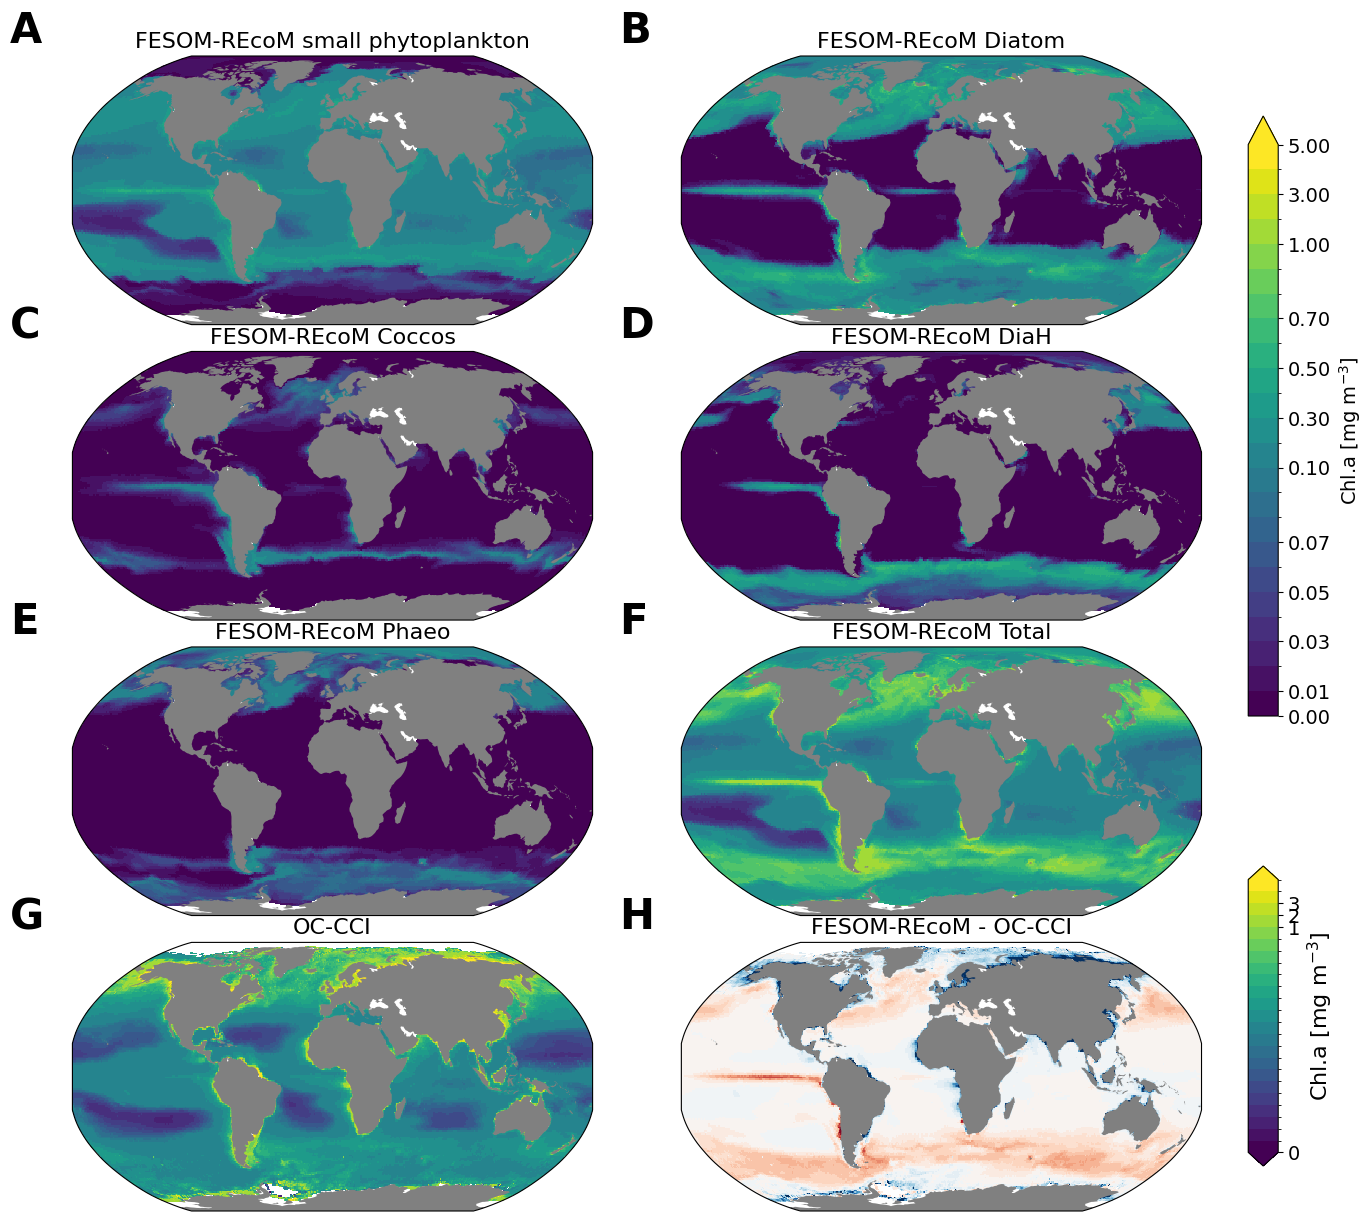


Statistics for log10 surface Chlorophyll

Original Taylor stats:
SDEV pred: 0.37495, ref: 0.44571
CRMS pred: 0.36986, ref: 0.00000
CORRCOEF: 0.60569

Normalized Taylor stats:
SDEV pred: 0.84124, ref: 1.00000
CRMS pred: 0.82984, ref: 0.00000
CORRCOEF: 0.60569


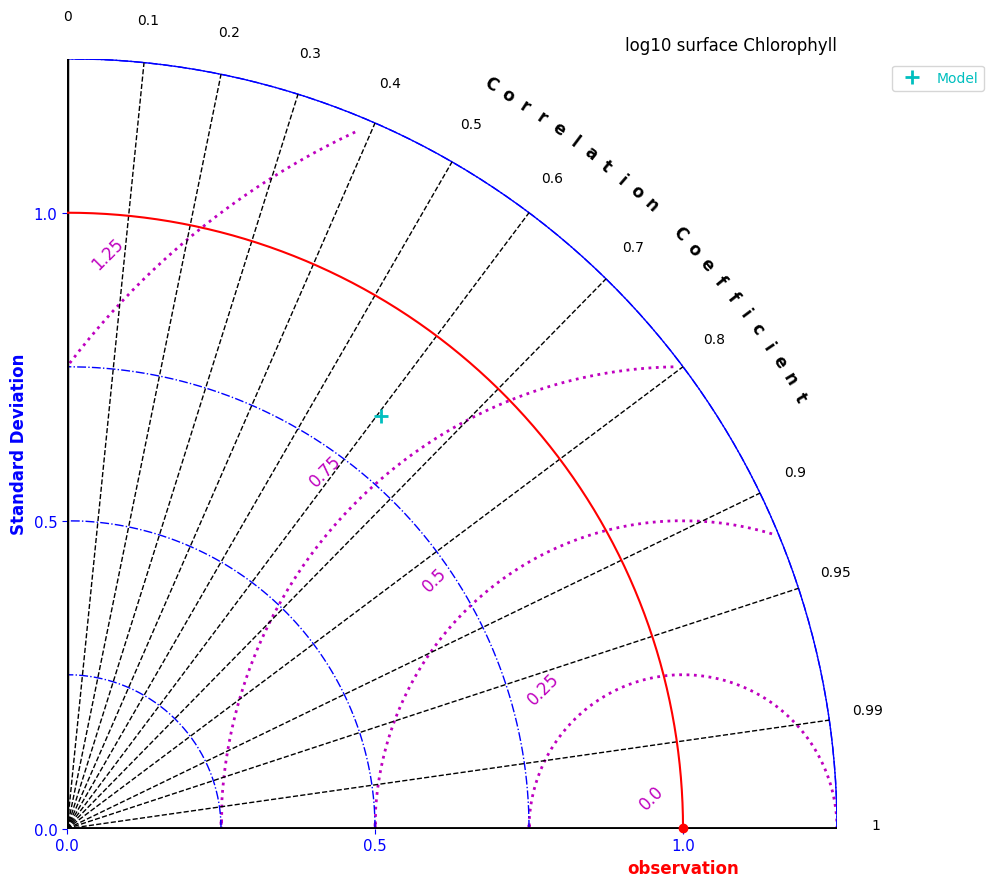

In [4]:
!jupyter nbconvert --to=python ChlGlobal.ipynb
from ChlGlobal import ChlGlobal
ChlGlobal(resultpath,savepath,mesh,matfileChlGloOCCCI,
          first_year_maps,last_year, savefig=savefig)

#### Southern Ocean Chl a [OC-CCI] <a class="anchor" id="OCCCIPPMAP"></a>

[NbConvertApp] Converting notebook ChlGlobal_SO.ipynb to python
[NbConvertApp] Writing 32431 bytes to ChlGlobal_SO.py
 !!! Satellite data only for 2012-2015 period !!!
4-phytoplankton model is used
5-phytoplankton model is used


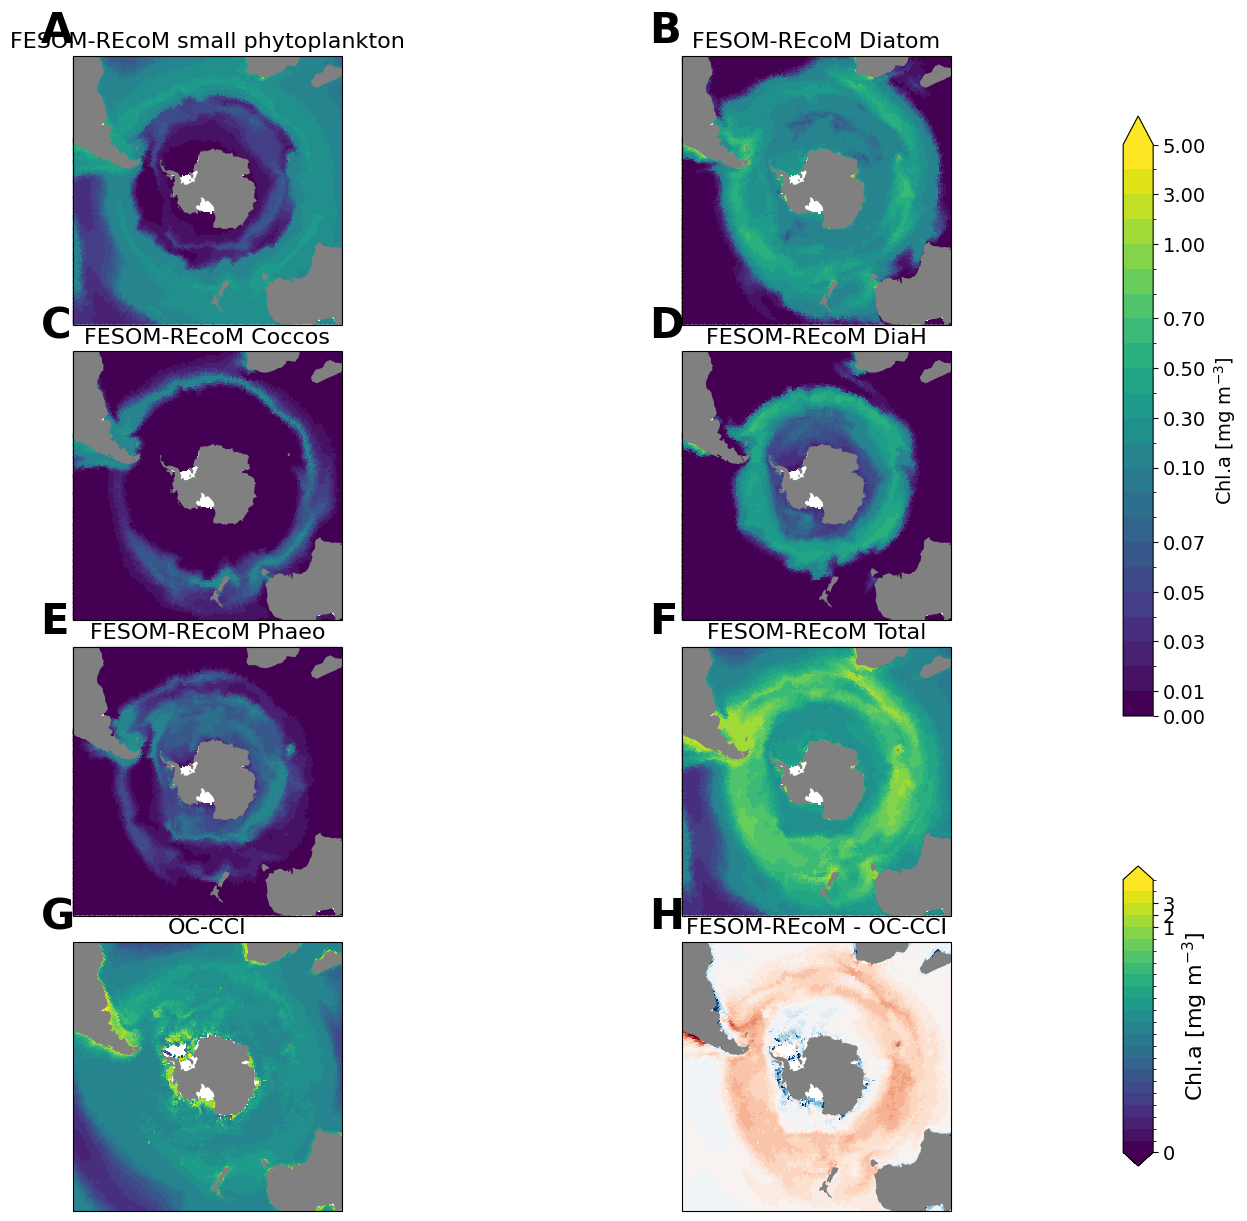


Statistics for log10 surface Chlorophyll

Original Taylor stats:
SDEV pred: 0.37495, ref: 0.44571
CRMS pred: 0.36986, ref: 0.00000
CORRCOEF: 0.60569

Normalized Taylor stats:
SDEV pred: 0.84124, ref: 1.00000
CRMS pred: 0.82984, ref: 0.00000
CORRCOEF: 0.60569


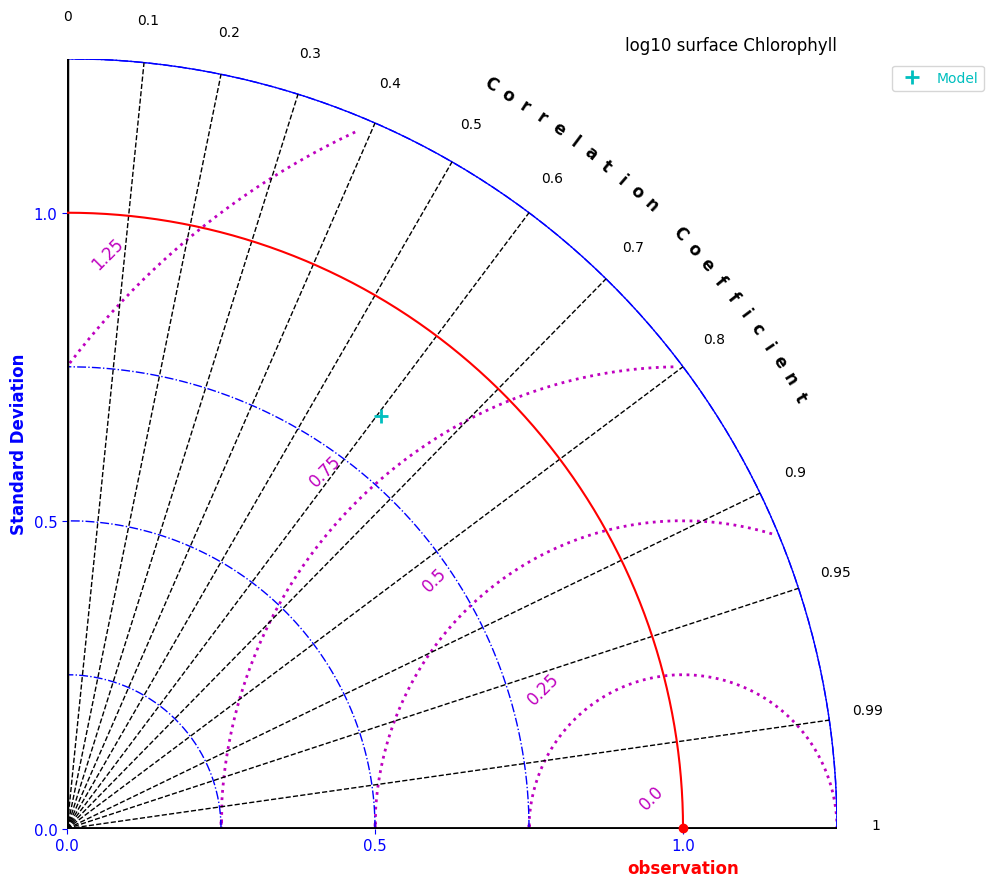

In [5]:
!jupyter nbconvert --to=python ChlGlobal_SO.ipynb
from ChlGlobal_SO import ChlGlobal_SO
ChlGlobal_SO(resultpath,savepath,mesh,matfileChlGloOCCCI,
          first_year_maps,last_year, mapproj='sp', savefig=savefig)

### 4.1.2 Southern ocean Chl a [Johnson et al. (2013)] <a class="anchor" id="JOHNPPMAP"></a>

In [ ]:
!jupyter nbconvert --to=python ChlSouthern.ipynb
from ChlSouthern import ChlSouthern
ChlSouthern(resultpath,savepath,mesh,ncfileChlSouthernJohnson,
                          first_year_maps,last_year,
                          savefig=savefig)

### 4.1.3 Arctic Ocean Chl a [Lewis et al. 2020 + OC-CCI]<a class="anchor" id="ARCCHLPMAP"></a>

In [ ]:
!jupyter nbconvert --to=python ChlArctic.ipynb
from ChlArctic import ChlArctic
ChlArctic(resultpath,savepath,mesh,ncfileChlArcLewis,
                          first_year_maps,last_year,savefig=savefig)

In [ ]:
!jupyter nbconvert --to=python ChlArctic.ipynb
from ChlArctic import ChlArctic
ChlArctic(resultpath,savepath,mesh,ncfileChlArcOCCCI,
                          first_year_maps,last_year,savefig=savefig)

### 4.1.4 Global Ocean NPP (cpbm & vgpn)<a class="anchor" id="NPPGLOBAL"></a>

In [ ]:
!jupyter nbconvert --to=python NPPGlobal.ipynb
from NPPGlobal import NPPGlobal

# analyze only last 10 years
# WARNING: here FESOM NPP is integrated and compared to Ocean Color NPP (surface)
NPPGlobal(resultpath, savepath, mesh, matfileNPPcpbm,
          first_year_maps, last_year, savefig=savefig)

In [ ]:
!jupyter nbconvert --to=python NPPGlobal.ipynb
from NPPGlobal import NPPGlobal

NPPGlobal(resultpath, savepath, mesh, matfileNPPvgpm,
                first_year_maps,last_year, savefig=savefig)

## Southern Ocean NPP projection (cpbm & vgpn)<a class="anchor" id="NPPGLOBAL"></a>

[NbConvertApp] Converting notebook NPPGlobal_SO.ipynb to python
[NbConvertApp] Writing 33262 bytes to NPPGlobal_SO.py
 !!! Satellite data for the 1998-2019 period only !!!
4-phytoplankton model is used
5-phytoplankton model is used
 NPP SAT Southern Ocean [PgC / yr] =  3.9206203734774023
 NPP REcoM Southern Ocean [PgC / yr] =  4.222204446230422
 NPP small phytoplankton REcoM Southern Ocean [PgC / yr] =  0.29943523500179653
 NPP diatoms REcoM Southern Ocean [PgC / yr] =  1.810811769849177
 NPP heavily silicified diatoms REcoM Southern Ocean [PgC / yr] =  1.3028997366142436
 NPP coccolithophores REcoM Southern Ocean [PgC / yr] =  0.019736171414990514
 NPP Phaeocystis REcoM Southern Ocean [PgC / yr] =  0.7893215283270737
 NPP SAT Global [PgC / yr] =  68.93480650824961
 NPP REcoM Global [PgC / yr] =  49.85247275677658
 NPP small phytoplankton REcoM Global [PgC / yr] =  30.82927115607277
 NPP diatoms REcoM Global [PgC / yr] =  11.711469714263131
 NPP heavily silicifying diatoms REcoM Global

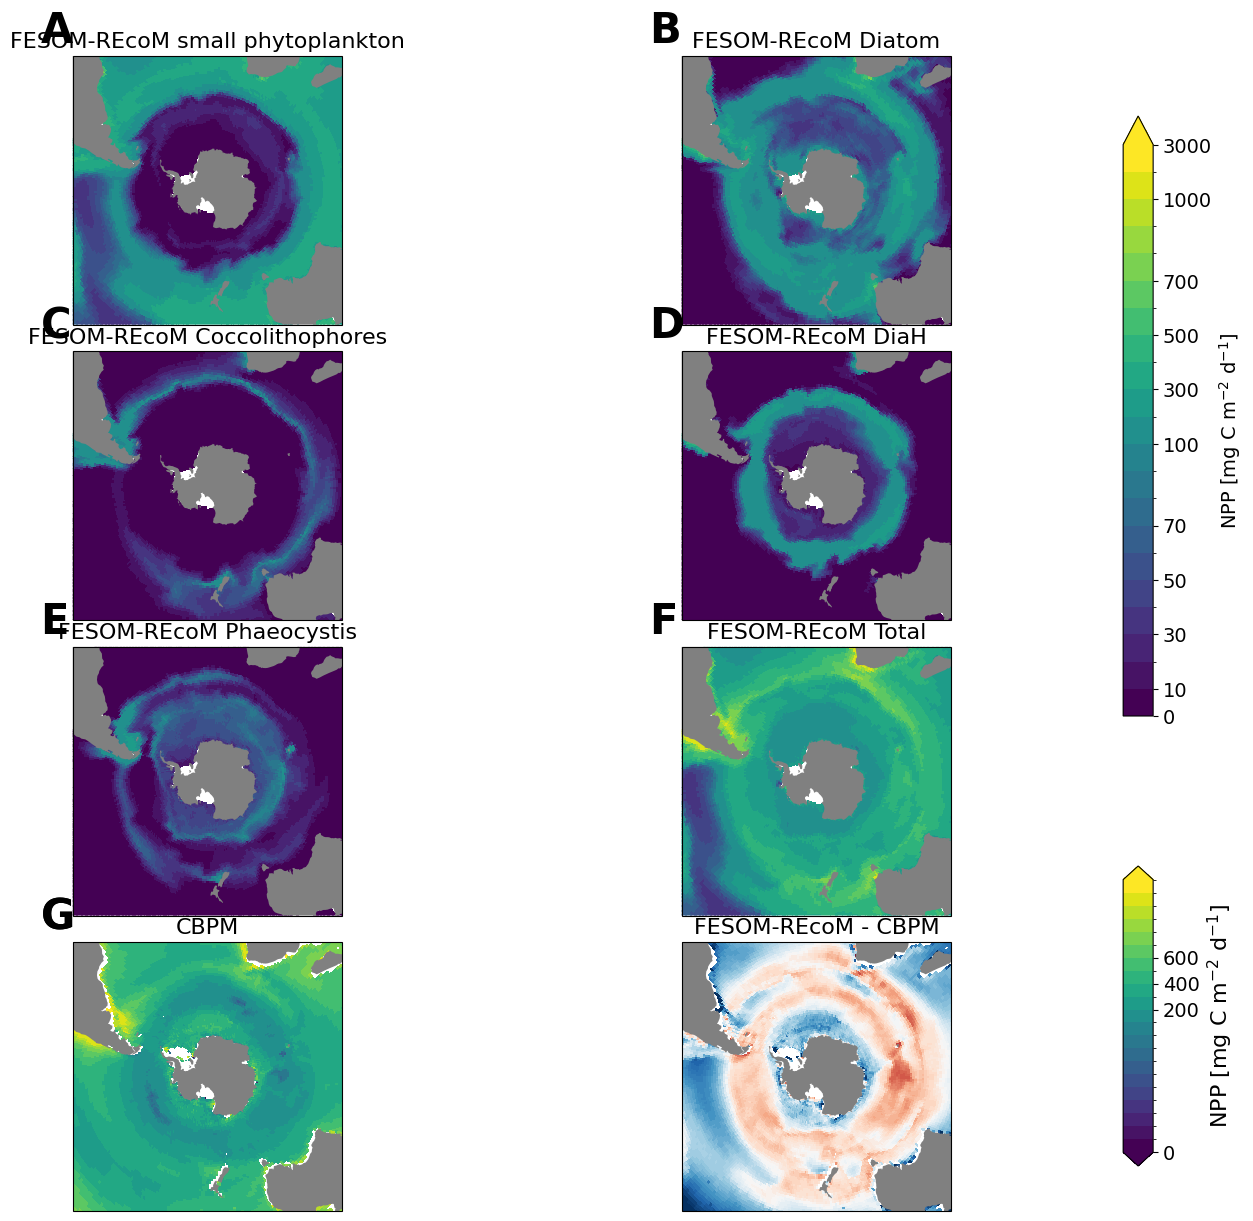


Statistics for log10 surface NPP

Original Taylor stats:
SDEV pred: 0.29894, ref: 0.24674
CRMS pred: 0.36654, ref: 0.00000
CORRCOEF: 0.10774

Normalized Taylor stats:
SDEV pred: 1.21156, ref: 1.00000
CRMS pred: 1.48553, ref: 0.00000
CORRCOEF: 0.10774
Adjust axis max to 1.5


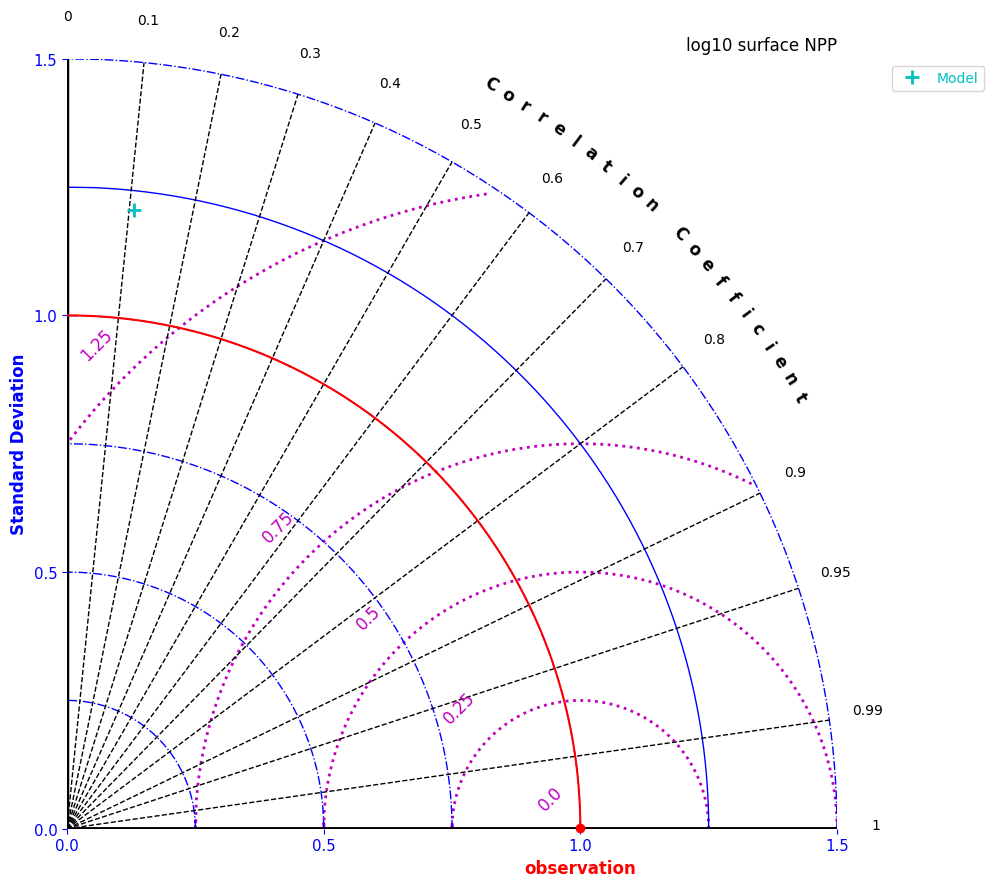

In [6]:
!jupyter nbconvert --to=python NPPGlobal_SO.ipynb
from NPPGlobal_SO import NPPGlobal_SO

# analyze only last 10 years
# WARNING: here FESOM NPP is integrated and compared to Ocean Color NPP (surface)
NPPGlobal_SO(resultpath, savepath, mesh, matfileNPPcpbm,
          first_year_maps, last_year, mapproj='sp', savefig=savefig)

### 4.1.5 Arctic Ocean NPP [Lewis et al. 2020 & Globcolour]<a class="anchor" id="#NPPARCTICMAP"></a>

In [ ]:
!jupyter nbconvert --to=python NPPArctic.ipynb
from NPPArctic import NPPArctic

NPPArctic(resultpath,savepath,mesh,npfileNPPArcLewis,
                          first_year_maps,last_year,savefig=savefig)

In [ ]:
!jupyter nbconvert --to=python NPPArctic.ipynb
from NPPArctic import NPPArctic

NPPArctic(resultpath,savepath,mesh,npfileNPParcCMEMS,
                          first_year_maps,last_year,savefig=savefig)

### 4.1.6 Maredat Biomass maps <a class="anchor" id="MAREDAT"></a>

[NbConvertApp] Converting notebook Biomass_maps_all_FT.ipynb to python
[NbConvertApp] Writing 18289 bytes to Biomass_maps_all_FT.py
Depth is None, 3d field will be returned
Upper depth: 0.0, Lower depth: -6000.0
Upper depth: 0.0, Lower depth: -6000.0
Depth is None, 3d field will be returned
Upper depth: 0.0, Lower depth: -6000.0
Upper depth: 0.0, Lower depth: -6000.0
Depth is None, 3d field will be returned
Upper depth: 0.0, Lower depth: -6000.0
Upper depth: 0.0, Lower depth: -6000.0
Depth is None, 3d field will be returned
Upper depth: 0.0, Lower depth: -6000.0
Upper depth: 0.0, Lower depth: -6000.0
Depth is None, 3d field will be returned
Upper depth: 0.0, Lower depth: -6000.0
Upper depth: 0.0, Lower depth: -6000.0
Depth is None, 3d field will be returned
Upper depth: 0.0, Lower depth: -6000.0
Upper depth: 0.0, Lower depth: -6000.0
Depth is None, 3d field will be returned
Upper depth: 0.0, Lower depth: -6000.0
Upper depth: 0.0, Lower depth: -6000.0
Depth is None, 3d field will be ret

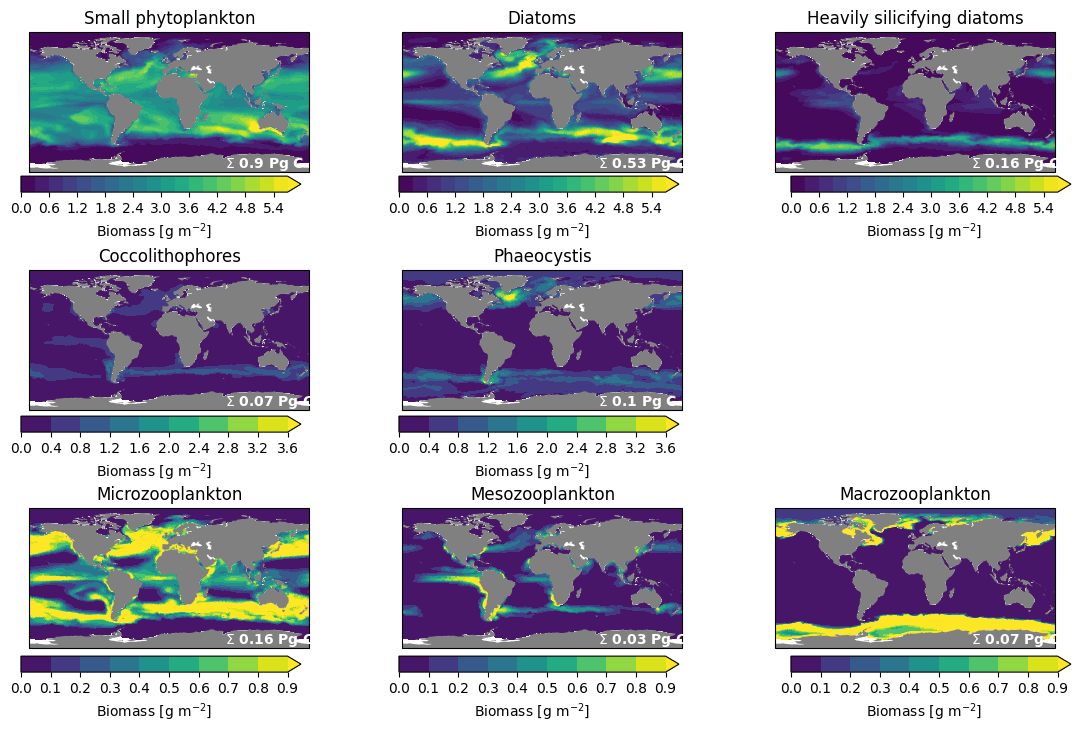

In [4]:
!jupyter nbconvert --to=python Biomass_maps_all_FT.ipynb
from Biomass_maps_all_FT import Bio_map_all

Bio_map_all(resultpath,savepath,mesh,meshpath,first_year_maps,last_year)

#### Diatoms

In [ ]:
!jupyter nbconvert --to=python Biomass_Maredat.ipynb
from Biomass_Maredat import Bio_comp

Bio_comp(resultpath,savepath,mesh,meshpath,ncfileMaredatDia,'DiaC',
                          first_year_maps,last_year)

#### Heavily silicifying diatoms

[NbConvertApp] Converting notebook Biomass_Maredat.ipynb to python
[NbConvertApp] Writing 5920 bytes to Biomass_Maredat.py
Depth is None, 3d field will be returned

Original Taylor stats:
SDEV pred: 19.60573, ref: 946.32927
CRMS pred: 946.06096, ref: 0.00000
CORRCOEF: 0.02404

Normalized Taylor stats:
SDEV pred: 0.02072, ref: 1.00000
CRMS pred: 0.99972, ref: 0.00000
CORRCOEF: 0.02404

Original Taylor stats:
SDEV pred:    nan, ref:    nan
CRMS pred:    nan, ref: 0.00000
CORRCOEF:    nan

Normalized Taylor stats:
SDEV pred:    nan, ref:    nan
CRMS pred:    nan, ref:    nan
CORRCOEF:    nan

Original Taylor stats:
SDEV pred:    nan, ref:    nan
CRMS pred:    nan, ref: 0.00000
CORRCOEF:    nan

Normalized Taylor stats:
SDEV pred:    nan, ref:    nan
CRMS pred:    nan, ref:    nan
CORRCOEF:    nan

Original Taylor stats:
SDEV pred:    nan, ref:    nan
CRMS pred:    nan, ref: 0.00000
CORRCOEF:    nan

Normalized Taylor stats:
SDEV pred:    nan, ref:    nan
CRMS pred:    nan, ref:    nan
COR

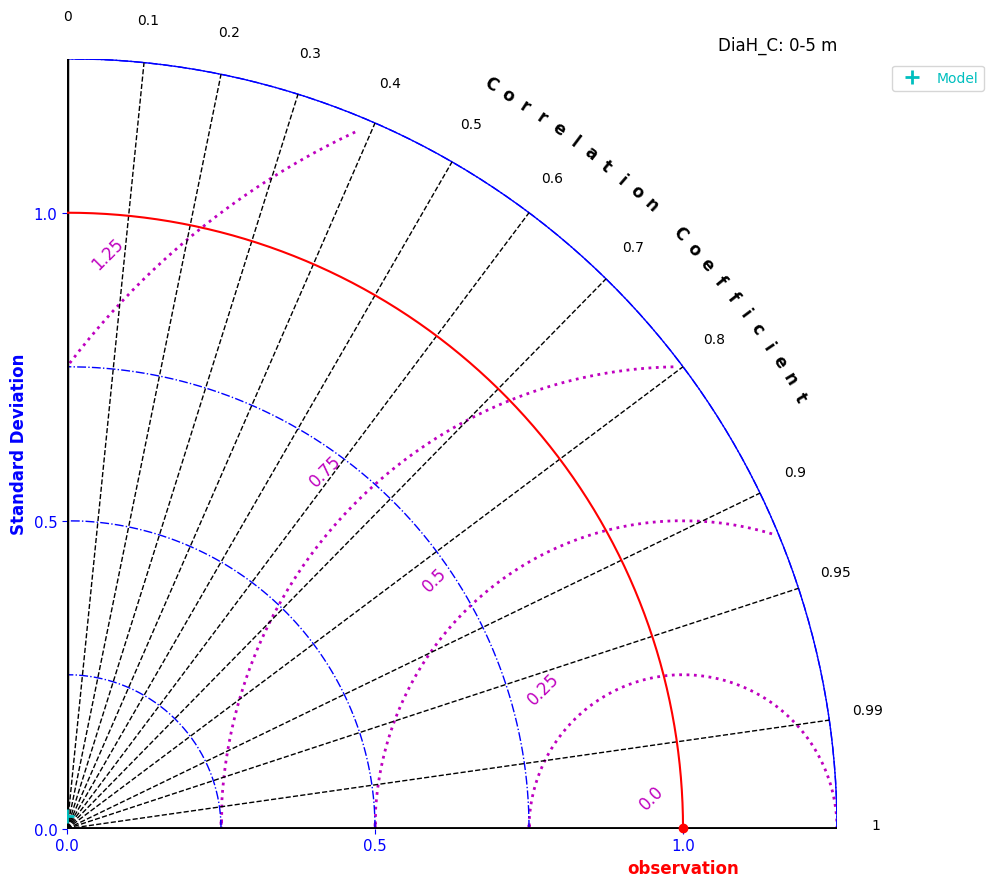

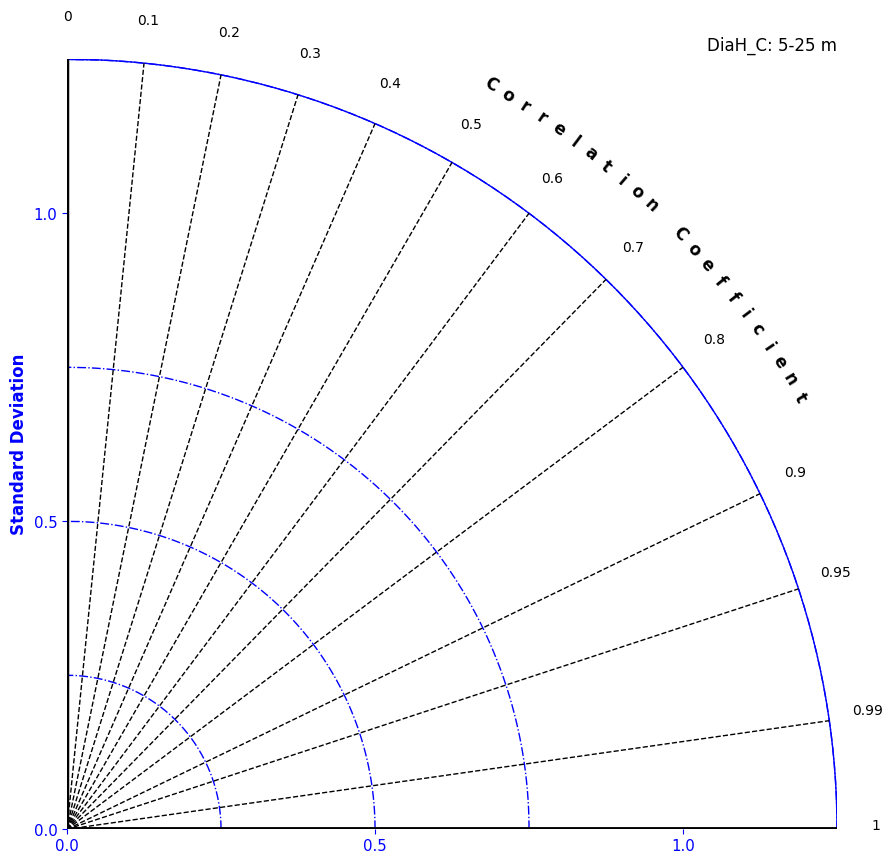

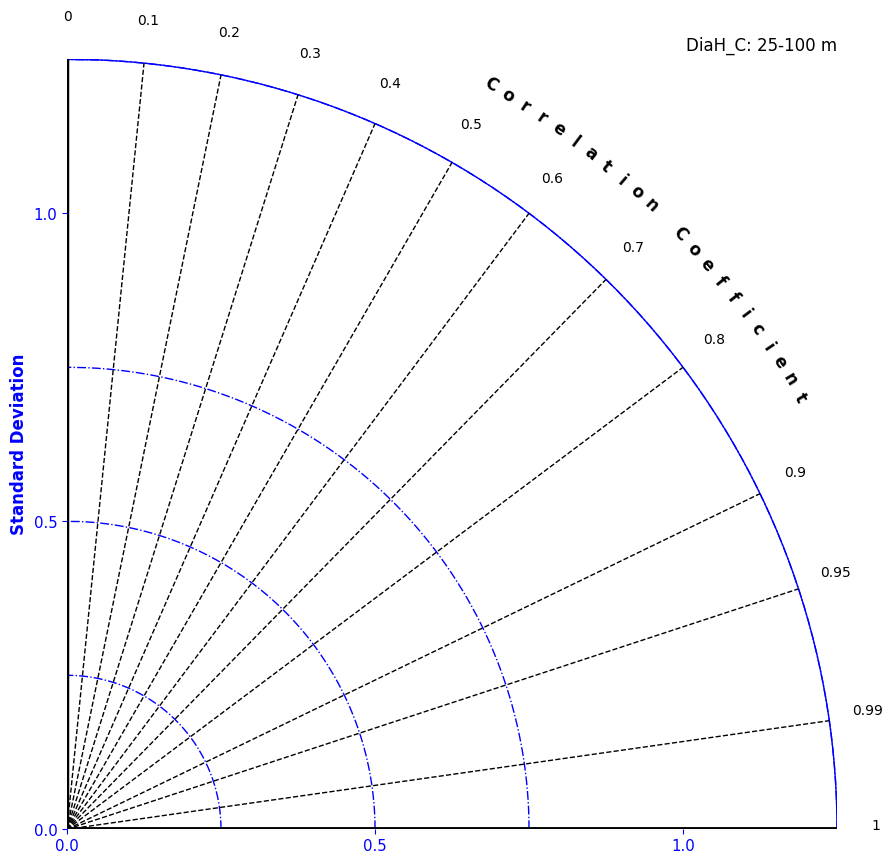

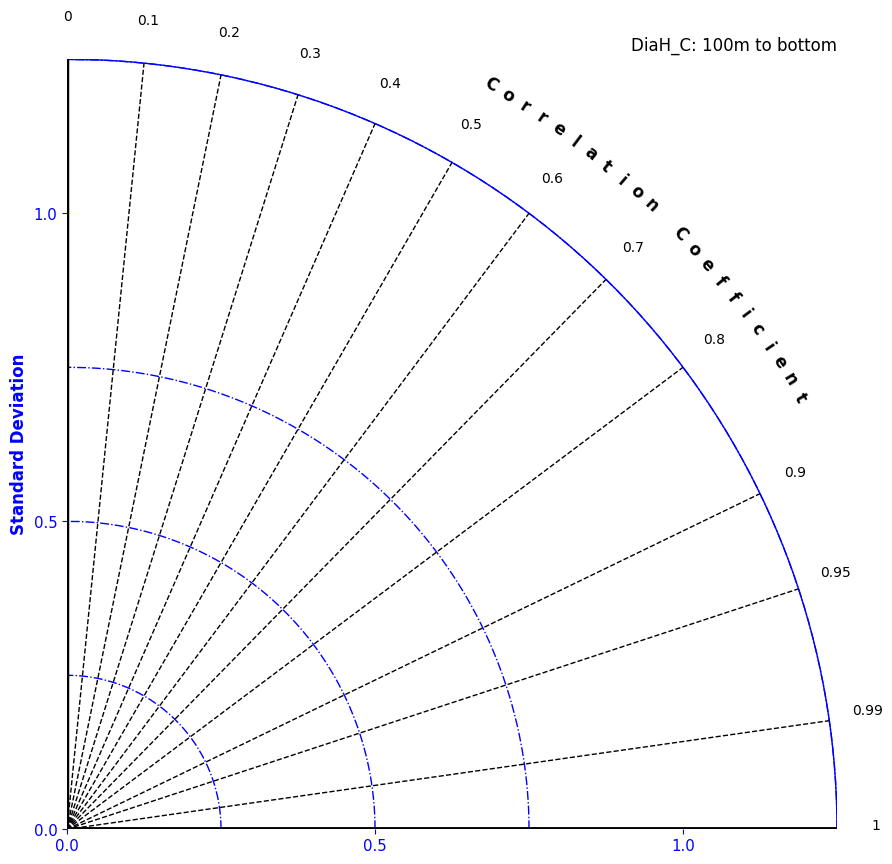

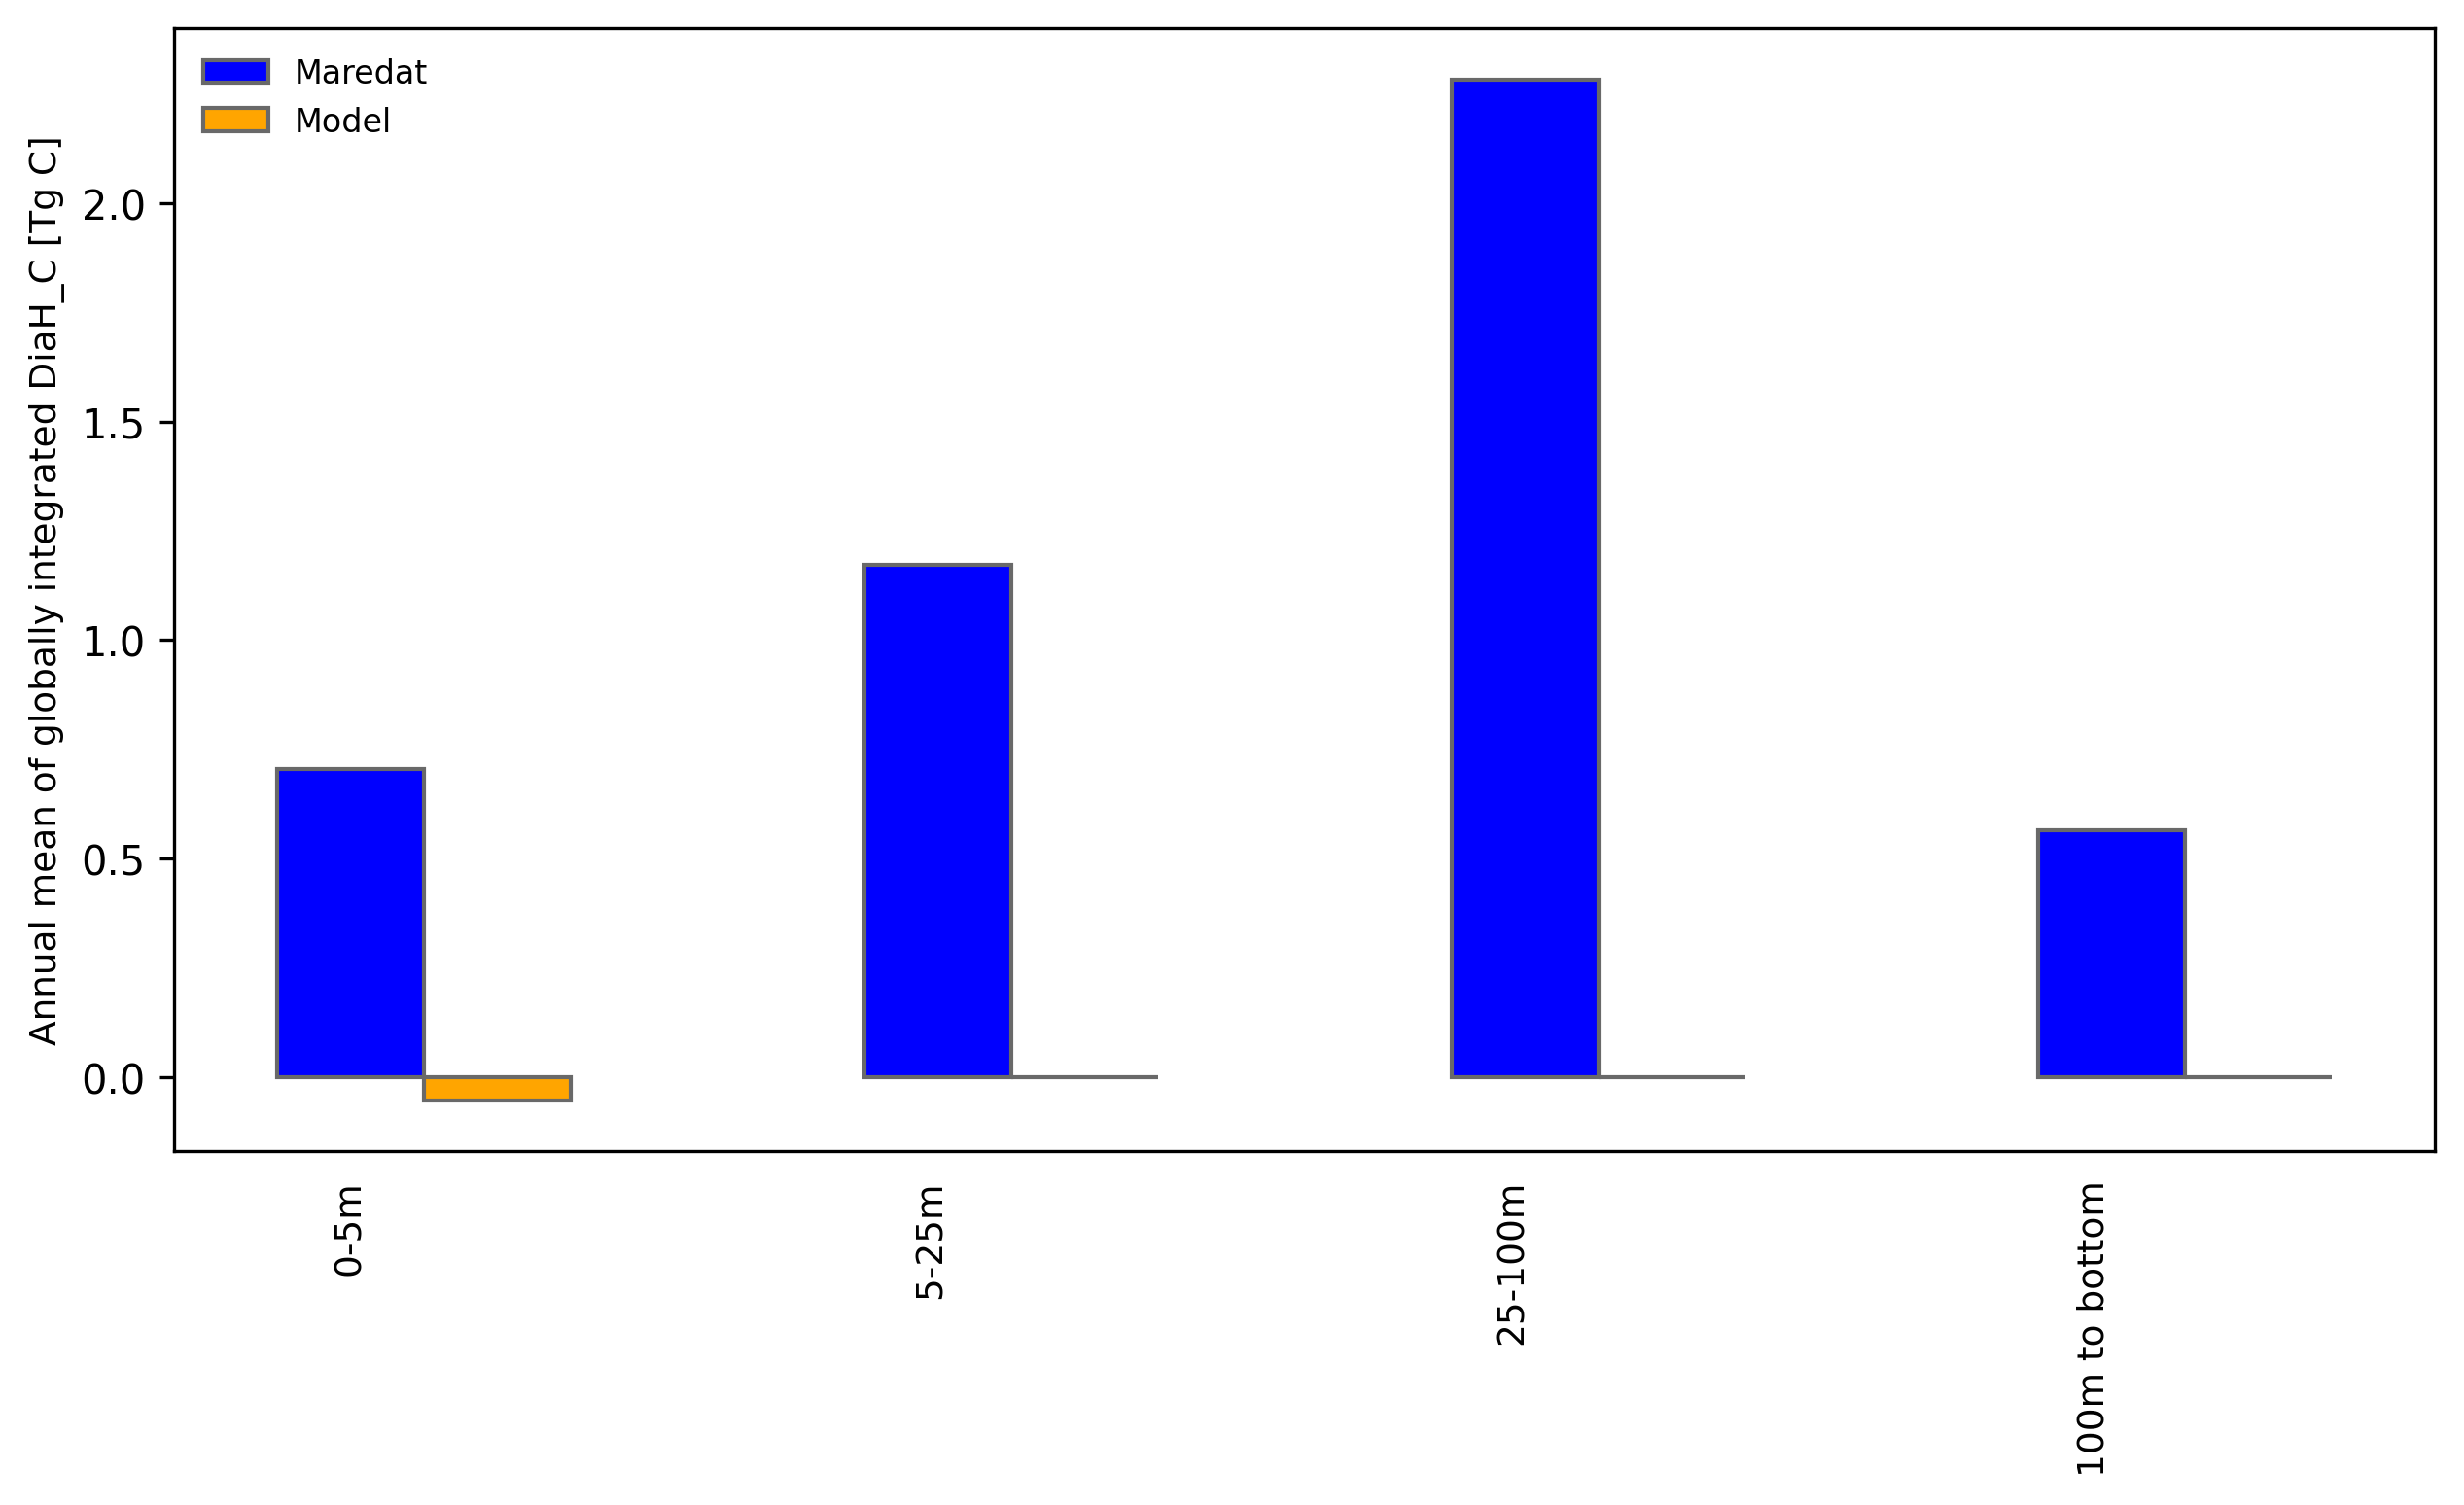

In [5]:
### doesn't make sense here
!jupyter nbconvert --to=python Biomass_Maredat.ipynb
from Biomass_Maredat import Bio_comp

from pathlib import Path
diaH_path = Path(resultpath + '/DiaH_C.fesom.'+str(years[0])+'.nc') # assuming that DiaH were used for the entire simulation if they were used in the first year of simulation
if diaH_path.is_file():
    Bio_comp(resultpath,savepath,mesh,meshpath,ncfileMaredatDia,'DiaH_C',
                              first_year_maps,last_year)
else:
    print('Sorry, model was used without DiaH')
# need to sum back dia and diaH for such comparison? 
# Maredat data does not differentiate between weakly and heavily silicified diatoms
# Other data to compare?

#### Coccolithophores

In [ ]:
!jupyter nbconvert --to=python Biomass_Maredat.ipynb
from Biomass_Maredat import Bio_comp

from pathlib import Path
cocco_path = Path(resultpath + '/CoccoC.fesom.'+str(years[0])+'.nc') # assuming that coccos were used for the entire simulation if they were used in the first year of simulation
if cocco_path.is_file():
    Bio_comp(resultpath,savepath,mesh,meshpath,ncfileMaredatCocco,'CoccoC',
                              first_year_maps,last_year)
else:
    print('Sorry, model was used without coccolithophores')

#### Phaeocystis

In [ ]:
!jupyter nbconvert --to=python Biomass_Maredat.ipynb
from Biomass_Maredat import Bio_comp

from pathlib import Path
phaeo_path = Path(resultpath + '/PhaeoC.fesom.'+str(years[0])+'.nc') # assuming that coccos were used for the entire simulation if they were used in the first year of simulation
if phaeo_path.is_file():
    Bio_comp(resultpath,savepath,mesh,meshpath,ncfileMaredatPhaeo,'PhaeoC',
                              first_year_maps,last_year)
else:
    print('Sorry, model was used without phaeocystis')

#### Microzooplankton

In [ ]:
!jupyter nbconvert --to=python Biomass_Maredat.ipynb
from Biomass_Maredat import Bio_comp

from pathlib import Path
micro_path = Path(resultpath + '/Zoo3C.fesom.'+str(years[0])+'.nc') # assuming that microzooplankton was used for the entire simulation if it was used in the first year of simulation
if micro_path.is_file():
    Bio_comp(resultpath,savepath,mesh,meshpath,ncfileMaredatMicro,'Zoo3C',
                              first_year_maps,last_year)
else:
    print('Sorry, model was used without microzooplankton (third zooplankton)')  

#### Mesozooplankton

In [ ]:
!jupyter nbconvert --to=python Biomass_Maredat.ipynb
from Biomass_Maredat import Bio_comp

Bio_comp(resultpath,savepath,mesh,meshpath,ncfileMaredatMeso,'HetC',
                          first_year_maps,last_year)

#### Mesozooplankton

In [ ]:
!jupyter nbconvert --to=python Biomass_Maredat.ipynb
from Biomass_Maredat import Bio_comp

from pathlib import Path
micro_path = Path(resultpath + '/Zoo2C.fesom.'+str(years[0])+'.nc') # assuming that macrozooplankton was used for the entire simulation if it was used in the first year of simulation
if micro_path.is_file():
    Bio_comp(resultpath,savepath,mesh,meshpath,ncfileMaredatMacro,'Zoo2C',
                              first_year_maps,last_year)
else:
    print('Sorry, model was used without macrozooplankton (second zooplankton / krill)')  

### 4.1.7 Limiting Factors <a class="anchor" id="LIMFACT"></a>

## 4.2 Latitudinal distributions<a class="anchor" id="LATPP"></a>

[NbConvertApp] Converting notebook Chl_NPP_latitudinal.ipynb to python
[NbConvertApp] Writing 8912 bytes to Chl_NPP_latitudinal.py
[NbConvertApp] Converting notebook ChlGlobal.ipynb to python
[NbConvertApp] Writing 32403 bytes to ChlGlobal.py
[NbConvertApp] Converting notebook ChlSouthern.ipynb to python
[NbConvertApp] Writing 18946 bytes to ChlSouthern.py
[NbConvertApp] Converting notebook NPPGlobal.ipynb to python
[NbConvertApp] Writing 31411 bytes to NPPGlobal.py
 !!! Satellite data for the 1998-2019 period only !!!
4-phytoplankton model is used
5-phytoplankton model is used
 NPP SAT Southern Ocean [PgC / yr] =  3.9206203734774023
 NPP REcoM Southern Ocean [PgC / yr] =  4.222204446230422
 NPP SAT Global [PgC / yr] =  68.93480650824961
 NPP REcoM Global [PgC / yr] =  49.85247275677658
 !!! Satellite data for the 1998-2019 period only !!!
4-phytoplankton model is used
5-phytoplankton model is used
 NPP SAT Southern Ocean [PgC / yr] =  3.482732855576151
 NPP REcoM Southern Ocean [PgC /

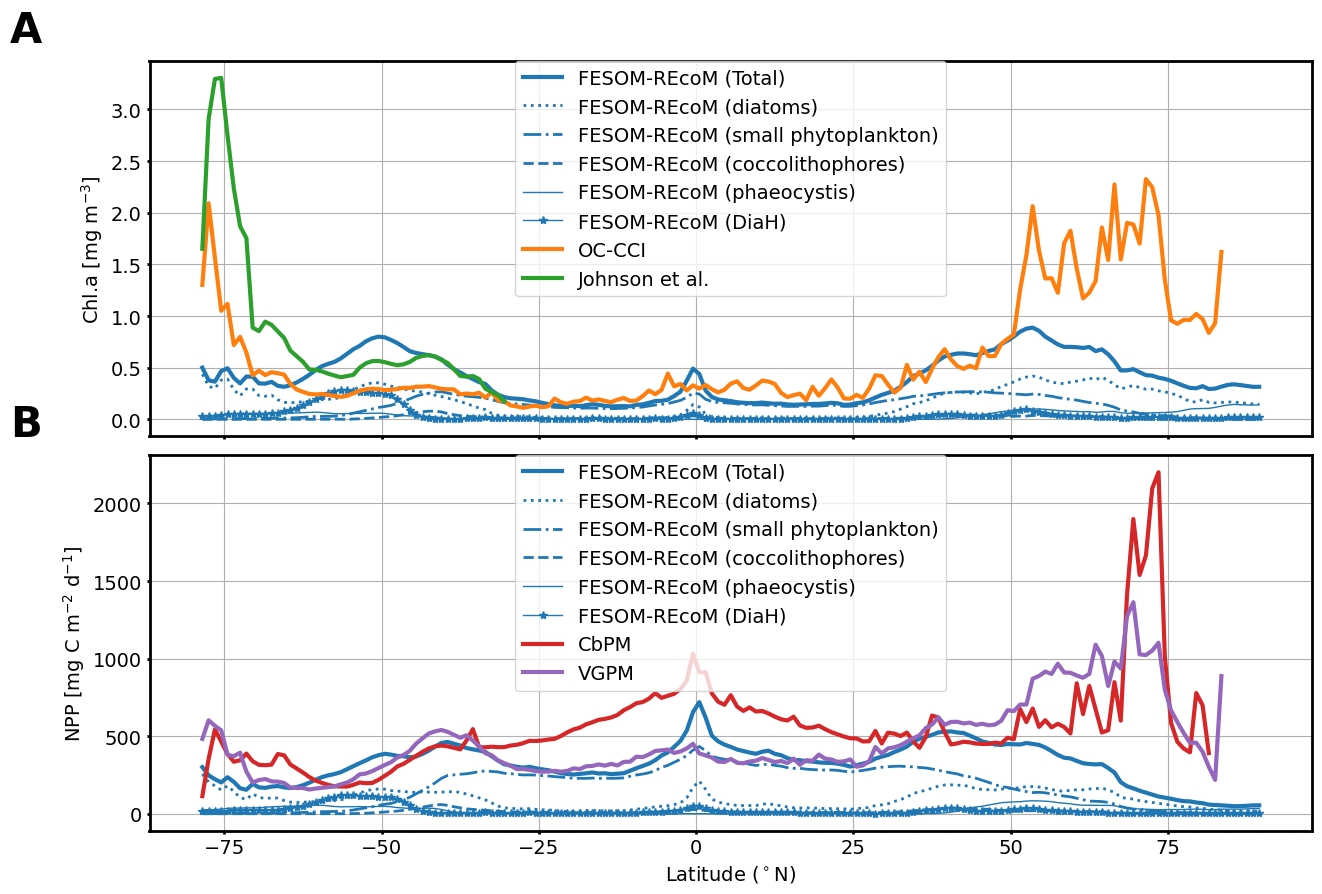

In [6]:
!jupyter nbconvert --to=python Chl_NPP_latitudinal.ipynb
!jupyter nbconvert --to=python ChlGlobal.ipynb
!jupyter nbconvert --to=python ChlSouthern.ipynb
!jupyter nbconvert --to=python NPPGlobal.ipynb
from Chl_NPP_latitudinal import Chl_NPP_lat_comp

Chl_NPP_lat_comp(resultpath,savepath,mesh,
                            matfileChlGloOCCCI,ncfileChlSouthernJohnson,matfileNPPcpbm,matfileNPPvgpm,
                            first_year_maps,last_year, savefig=savefig)

## 4.3 Time series<a class="anchor" id="TSPP"></a>

In [ ]:
# time-series of NPP and export production
!jupyter nbconvert --to=python NPP_timeseries.ipynb
from NPP_timeseries import NPP_timeseries
NPP_timeseries(resultpath,savepath,mesh,first_year_maps,last_year,savefig=savefig,mask="Global Ocean")
### export production --> gravitational sinking of detritus out of 100 m depth

In [ ]:
# Example for the Southern Ocean only
!jupyter nbconvert --to=python NPP_timeseries.ipynb
from NPP_timeseries import NPP_timeseries
NPP_timeseries(resultpath,savepath,mesh,first_year_maps,last_year,savefig=savefig,mask="Southern_Ocean_50S")

In [ ]:
!jupyter nbconvert --to=python NPP_timeseries.ipynb
from NPP_timeseries import NPP_timeseries
NPP_timeseries(resultpath,savepath,mesh,first_year,last_year,savefig=savefig,mask="Arctic_Basin")

## 4.4 Seasonal cycle<a class="anchor" id="SCyc"></a>




### 4.4.1 Chl-a<a class="anchor" id="SCycChla"></a>

In [ ]:
!jupyter nbconvert --to=python SeasonalCycle.ipynb
from SeasonalCycle import SeasonalCycle

SeasonalCycle(resultpath,savepath,mesh,first_year,last_year,type="Chl",savefig=False)

### 4.4.2 NPP<a class="anchor" id="SCycNPP"></a>

[NbConvertApp] Converting notebook SeasonalCycle.ipynb to python
[NbConvertApp] Writing 19496 bytes to SeasonalCycle.py


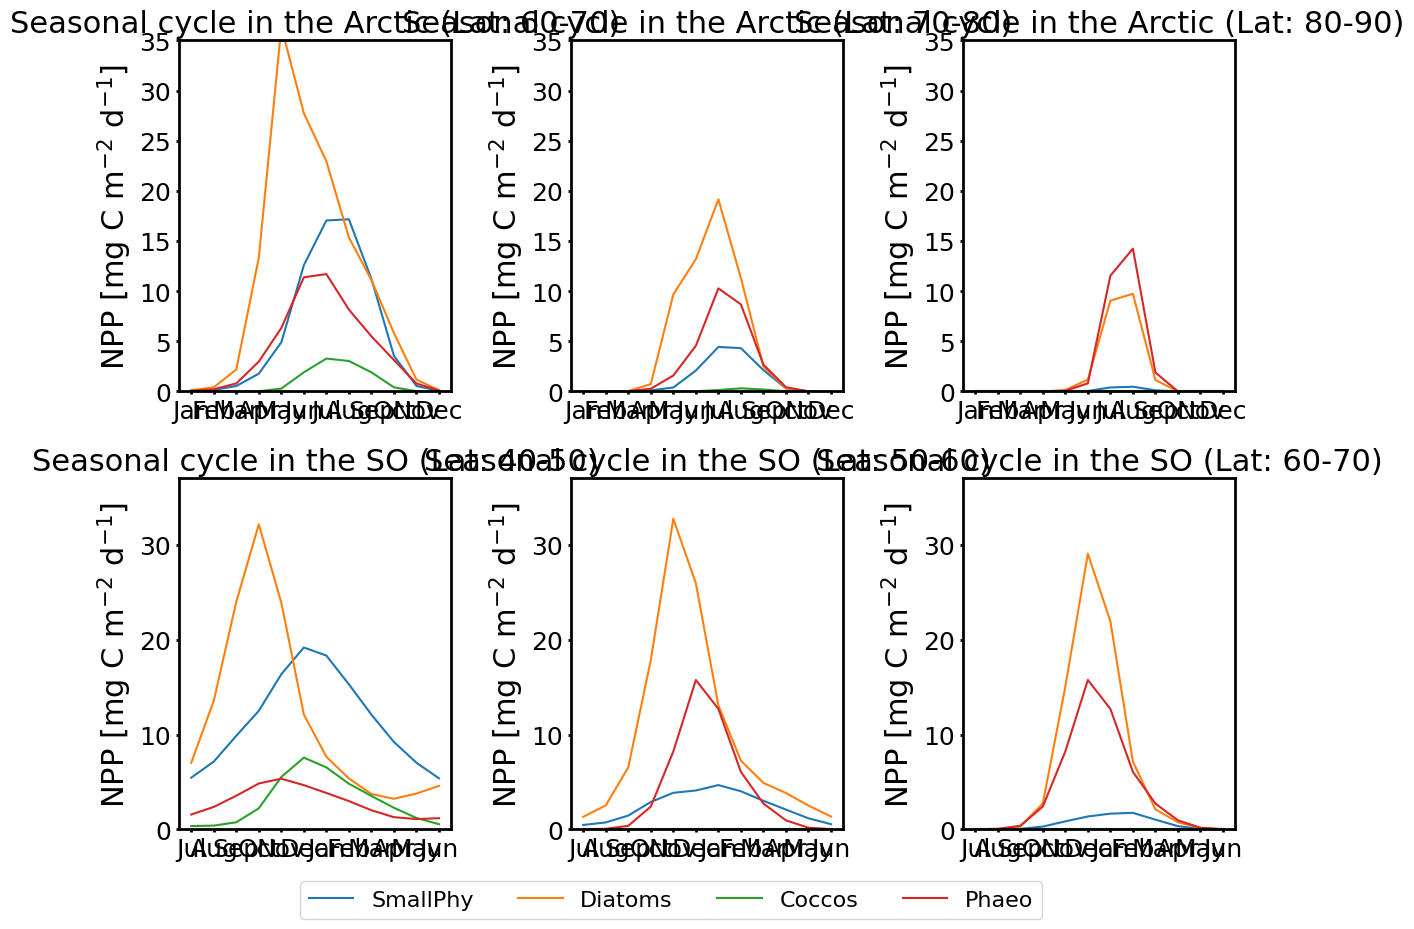

In [8]:
!jupyter nbconvert --to=python SeasonalCycle.ipynb
from SeasonalCycle import SeasonalCycle

SeasonalCycle(resultpath,savepath,mesh,first_year,last_year,type="NPP",savefig=False)

# Save notebook as html

In [ ]:
%%javascript
IPython.notebook.kernel.execute('nb_name = "' + IPython.notebook.notebook_name + '"')
%autosave
!jupyter nbconvert $nb_name --output-dir=$htmlpath --to html --no-input